# TABVERSE — Task Evaluation Analysis

Comprehensive breakdown for the paper result section.

| Section | Focus |
|---------|-------|
| **1. Primary Table** | Overall accuracy: HTML / LaTeX / Markdown |
| **2. Category Analysis** ⭐ | 7 question categories × 100 samples each |
| **3. Difficulty Analysis** ⭐ | Easy (350) vs Hard (350) |
| **4. Dataset Analysis** | 5 datasets (wikitq, hybridqa, sqa, tabfact, feverous) |

All figures and CSV exports → `results/final_csv/`

In [1]:
import json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

matplotlib.rcParams['figure.dpi'] = 130
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_rows', 100)


In [2]:
# ── Auto-detect TABVERSE root ──────────────────────────────────────────
def _find_root():
    cwd = Path.cwd()
    for _ in range(6):
        if (cwd / 'results').exists() and (cwd / 'src').exists():
            return cwd
        cwd = cwd.parent
    raise RuntimeError("Cannot find TABVERSE root. Run from TABVERSE/ or src/evaluation/.")

TABVERSE_ROOT = _find_root()
RESULTS_DIR   = TABVERSE_ROOT / 'results'
FINAL_CSV_DIR = RESULTS_DIR   / 'scores'
FINAL_CSV_DIR.mkdir(parents=True, exist_ok=True)
print(f'TABVERSE root : {TABVERSE_ROOT}')

# ── Pipeline configs ────────────────────────────────────────────────────
PIPELINE_CONFIGS = {
    'VLM':      {'dir': 'vlmpipeline',      'pred_key': 'task_prediction'},
    'VLM-TEXT': {'dir': 'vlmpipeline_text', 'pred_key': 'task_prediction'},
    'LLM':      {'dir': 'llmpipeline',      'pred_key': 'task_prediction_processed'},
}
PIPELINE_ORDER = ['VLM', 'VLM-TEXT', 'LLM']
FORMATS        = ['html', 'latex', 'markdown']

# ── Taxonomy ────────────────────────────────────────────────────────────
CATEGORIES = [
    'Simple Lookup',
    'Conditional Lookup',
    'Multi-Item Lookup',
    'Aggregation / Counting / Arithmetic',
    'Comparison & Extremum',
    'Single-step Binary Verification',
    'Multi-hop Binary Verification',
]
CAT_SHORT = {
    'Simple Lookup':                        'SL',
    'Conditional Lookup':                   'CL',
    'Multi-Item Lookup':                    'MIL',
    'Aggregation / Counting / Arithmetic':  'ACA',
    'Comparison & Extremum':                'CE',
    'Single-step Binary Verification':      'SBV',
    'Multi-hop Binary Verification':        'MBV',
}
DIFFICULTIES = ['Easy', 'Hard']
DATASETS     = ['wikitq', 'hybridqa', 'sqa', 'tabfact', 'feverous']

TABVERSE root : /home/momina.ahsan/TABVERSE


In [3]:
# ── EM evaluation helpers ───────────────────────────────────────────────
def _clean(text):
    return re.sub(r'\s+', ' ', str(text).strip().lower())

def _is_error(s):
    s = (s or '').strip().lower()
    return s.startswith('error') or s in {'connection_failed', 'extraction_failed', ''}

def _split_multi(text):
    """Split a multi-item prediction string on , ; or \\n → sorted cleaned list."""
    parts = re.split(r'[,;\n]+', str(text))
    return sorted([_clean(p) for p in parts if _clean(p)])

def _soft_match(guess, gold):
    """
    True if guess matches gold using:
      1. Exact match after _clean normalisation.
      2. Gold is a leading substring of guess (model appended extra context,
         e.g. 'soviet union (16)' vs gold 'soviet union'), provided the
         character immediately after the gold prefix is not alphanumeric.
    """
    if guess == gold:
        return True
    if guess.startswith(gold) and len(guess) > len(gold):
        if not guess[len(gold)].isalnum():
            return True
    return False

def _check_em(row, fmt, pred_key):
    """True = correct, False = wrong, None = prediction missing.

    Multi-Item Lookup: prediction is split on , ; \\n and compared as a
    sorted set against the gold label list.
    All other categories: soft exact match — accepts predictions that have
    the gold answer as a leading substring (handles model appending extra
    context like parenthesised counts or dashes with extra info).
    """
    pred_block = row.get(fmt) or {}
    if pred_key not in pred_block:
        return None
    gold = row.get('label')
    if gold is None:
        return None

    raw_pred = pred_block[pred_key]
    golds = [_clean(g) for g in (gold if isinstance(gold, list) else [gold]) if g is not None]

    category = row.get('question_category', '')
    if category == 'Multi-Item Lookup':
        return _split_multi(raw_pred) == sorted(golds)
    else:
        guess = _clean(raw_pred)
        if _is_error(guess):
            return False
        return any(_soft_match(guess, g) for g in golds)

# ── Load flat DataFrame ────────────────────────────────────────────────
def load_all_records():
    records = []
    for pipeline_label, cfg in PIPELINE_CONFIGS.items():
        pipeline_dir = RESULTS_DIR / cfg['dir']
        if not pipeline_dir.exists():
            continue
        for model_dir in sorted(pipeline_dir.iterdir()):
            task_file = model_dir / 'task.json'
            if not task_file.exists():
                continue
            with open(task_file, encoding='utf-8') as f:
                rows = json.load(f)
            for row in rows:
                rec = {
                    'pipeline':            pipeline_label,
                    'model':               model_dir.name,
                    'id':                  row.get('id'),
                    'question_category':   row.get('question_category'),
                    'question_difficulty': row.get('question_difficulty'),
                    'dataset':             row.get('dataset'),
                }
                for fmt in FORMATS:
                    rec[f'{fmt}_em'] = _check_em(row, fmt, cfg['pred_key'])
                records.append(rec)
    return pd.DataFrame(records)

print('Loading all task.json files...')
df = load_all_records()
print(f'Loaded {len(df):,} records  '
      f'[{df["pipeline"].nunique()} pipelines, {df["model"].nunique()} models]')


Loading all task.json files...
Loaded 21,700 records  [3 pipelines, 18 models]


In [4]:
# ── Accuracy utilities ────────────────────────────────────────────────
def _acc(series):
    valid = series.dropna()
    return round(float(valid.mean()) * 100, 2) if len(valid) > 0 else None

def compute_accuracy(data, group_cols):
    """
    Compute html_acc / latex_acc / markdown_acc / avg_acc
    grouped by group_cols.  Pipeline rows are sorted in PIPELINE_ORDER.
    """
    rows = []
    for keys, grp in data.groupby(group_cols, sort=True):
        keys = keys if isinstance(keys, tuple) else (keys,)
        rec  = dict(zip(group_cols, keys))
        fmt_accs = []
        for fmt in FORMATS:
            a = _acc(grp[f'{fmt}_em'])
            rec[f'{fmt}_acc'] = a
            if a is not None:
                fmt_accs.append(a)
        rec['avg_acc'] = round(sum(fmt_accs) / len(fmt_accs), 2) if fmt_accs else None
        rows.append(rec)
    result = pd.DataFrame(rows)
    if 'pipeline' in result.columns:
        result['pipeline'] = pd.Categorical(
            result['pipeline'], categories=PIPELINE_ORDER, ordered=True)
        other = [c for c in group_cols if c != 'pipeline']
        result = result.sort_values(['pipeline'] + other).reset_index(drop=True)
    return result

# Pre-compute overall accuracy per (pipeline, model)
overall = compute_accuracy(df, ['pipeline', 'model'])

print('Coverage — records per pipeline × model:')
cov = (df.groupby(['pipeline', 'model']).size()
         .rename('records').reset_index()
         .pivot(index='model', columns='pipeline', values='records')
         .reindex(columns=PIPELINE_ORDER).fillna('—'))
display(cov)

Coverage — records per pipeline × model:


pipeline,VLM,VLM-TEXT,LLM
model,,,
InternVL3.5-14B,700.00,700.00,—
InternVL3.5-30B-A3B,700.00,700.00,—
Qwen2.5-7B-Instruct,—,—,700.00
Qwen3-30B-A3B-Instruct-2507,—,—,700.00
Qwen3-VL-30B-A3B-Instruct,700.00,700.00,—
Qwen3-VL-8B-Instruct,700.00,700.00,—
Qwen3.5-27B,700.00,—,—
SmolVLM2-2.2B-Instruct,700.00,700.00,—
TAMA-QWen3,—,—,700.00


---
## 1. Primary Results Table

Source: `results/scores/task.csv` (generated by `eval_task.py`).
Rows = models, Columns = HTML / LaTeX / Markdown overall accuracy (%).

In [5]:
task_csv = FINAL_CSV_DIR / 'task.csv'
if task_csv.exists():
    task_df = pd.read_csv(task_csv)
    # Remove blank separator rows
    task_df = task_df[task_df['model'].notna() & (task_df['model'] != '')].copy()
    for pipeline in PIPELINE_ORDER:
        sub = task_df[task_df['pipeline'] == pipeline].drop(columns='pipeline').reset_index(drop=True)
        if sub.empty:
            continue
        print(f'\n{" " + pipeline + " ":=^50}')
        display(sub)
else:
    print(f'task.csv not found. Run: python src/evaluation/eval_task.py')

task.csv not found. Run: python src/evaluation/eval_task.py


---
## 2. Question Category Analysis ⭐

7 categories, **100 samples each** (split across Easy / Hard).

| Abbrev | Full Name |
|--------|-----------|
| SL  | Simple Lookup |
| CL  | Conditional Lookup |
| MIL | Multi-Item Lookup |
| ACA | Aggregation / Counting / Arithmetic |
| CE  | Comparison & Extremum |
| SBV | Single-step Binary Verification |
| MBV | Multi-hop Binary Verification |

In [6]:
cat_acc = compute_accuracy(df, ['pipeline', 'model', 'question_category'])

# Wide table: rows = models, columns = categories (avg_acc)
cat_wide = (
    cat_acc
    .pivot_table(index=['pipeline', 'model'], columns='question_category',
                 values='avg_acc', observed=True)
    .reindex(columns=CATEGORIES)
    .rename(columns=CAT_SHORT)
    .reset_index()
)

print('Category accuracy (%) — avg over HTML / LaTeX / Markdown')
for pipeline in PIPELINE_ORDER:
    sub = cat_wide[cat_wide['pipeline'] == pipeline].drop(columns='pipeline').reset_index(drop=True)
    if sub.empty:
        continue
    # Sort by model's overall avg_acc
    ord_ = (overall[overall['pipeline'] == pipeline]
            .sort_values('avg_acc', ascending=False)['model'].tolist())
    sub['model'] = pd.Categorical(sub['model'], categories=ord_, ordered=True)
    sub = sub.sort_values('model').reset_index(drop=True)
    print(f'\n{" " + pipeline + " ":=^70}')
    display(sub.round(2))

Category accuracy (%) — avg over HTML / LaTeX / Markdown

================================ VLM =================================


question_category,model,SL,CL,MIL,ACA,CE,SBV,MBV
0,gemini-3-flash-preview,66.43,74.67,49.67,63.21,72.00,65.33,66.00
1,gpt-5.2,55.01,53.00,40.33,59.87,65.67,57.00,54.67
2,Qwen3-VL-8B-Instruct,58.00,35.33,37.33,31.67,48.00,70.00,68.00
3,InternVL3.5-30B-A3B,51.67,37.67,18.33,33.00,52.67,73.67,74.00
4,InternVL3.5-14B,49.67,36.00,25.33,29.33,57.00,75.67,64.67
5,gemma_3-27B-IT,50.33,31.67,26.33,29.00,39.00,71.00,72.00
6,ministral_3-14B-Instruct,45.33,40.00,19.33,28.67,51.33,54.67,55.33
7,Qwen3-VL-30B-A3B-Instruct,48.67,23.67,23.67,21.33,52.00,65.00,56.67
8,gemma_3-12B-IT,42.67,24.00,17.67,24.00,35.33,63.67,65.67
9,llava_1.6-vicuna-7B,26.67,10.67,1.67,9.67,16.67,79.00,78.00



============================== VLM-TEXT ==============================


question_category,model,SL,CL,MIL,ACA,CE,SBV,MBV
0,gemini-3-flash-preview,67.00,75.33,47.33,63.67,71.00,67.67,65.67
1,gpt-5.2,62.33,46.67,44.00,61.67,68.67,62.33,57.33
2,Qwen3-VL-8B-Instruct,58.00,33.00,45.33,37.00,49.00,73.67,74.67
3,gemma_3-27B-IT,57.00,40.33,40.67,37.00,49.33,68.00,76.00
4,gemma_3-12B-IT,58.00,36.00,40.67,26.00,44.67,68.67,71.00
5,InternVL3.5-30B-A3B,45.67,32.00,16.00,42.00,47.33,71.33,68.33
6,InternVL3.5-14B,54.33,36.33,16.33,38.00,45.33,64.33,63.67
7,Qwen3-VL-30B-A3B-Instruct,32.00,26.00,22.33,26.67,47.33,72.67,73.00
8,ministral_3-14B-Instruct,50.67,33.67,13.67,22.67,46.33,48.33,46.00
9,llava_1.6-vicuna-7B,9.26,3.67,5.39,7.01,14.71,75.27,77.30



================================ LLM =================================


question_category,model,SL,CL,MIL,ACA,CE,SBV,MBV
0,Qwen3-30B-A3B-Instruct-2507,48.00,29.67,32.33,29.67,45.67,77.00,78.67
1,Qwen2.5-7B-Instruct,52.67,32.67,37.00,26.67,43.00,59.67,58.00
2,TableGPT2-7B,40.00,27.67,30.67,21.67,33.00,73.33,72.67
3,TAMA-QWen3,1.00,0.00,0.00,2.00,0.00,72.00,73.00


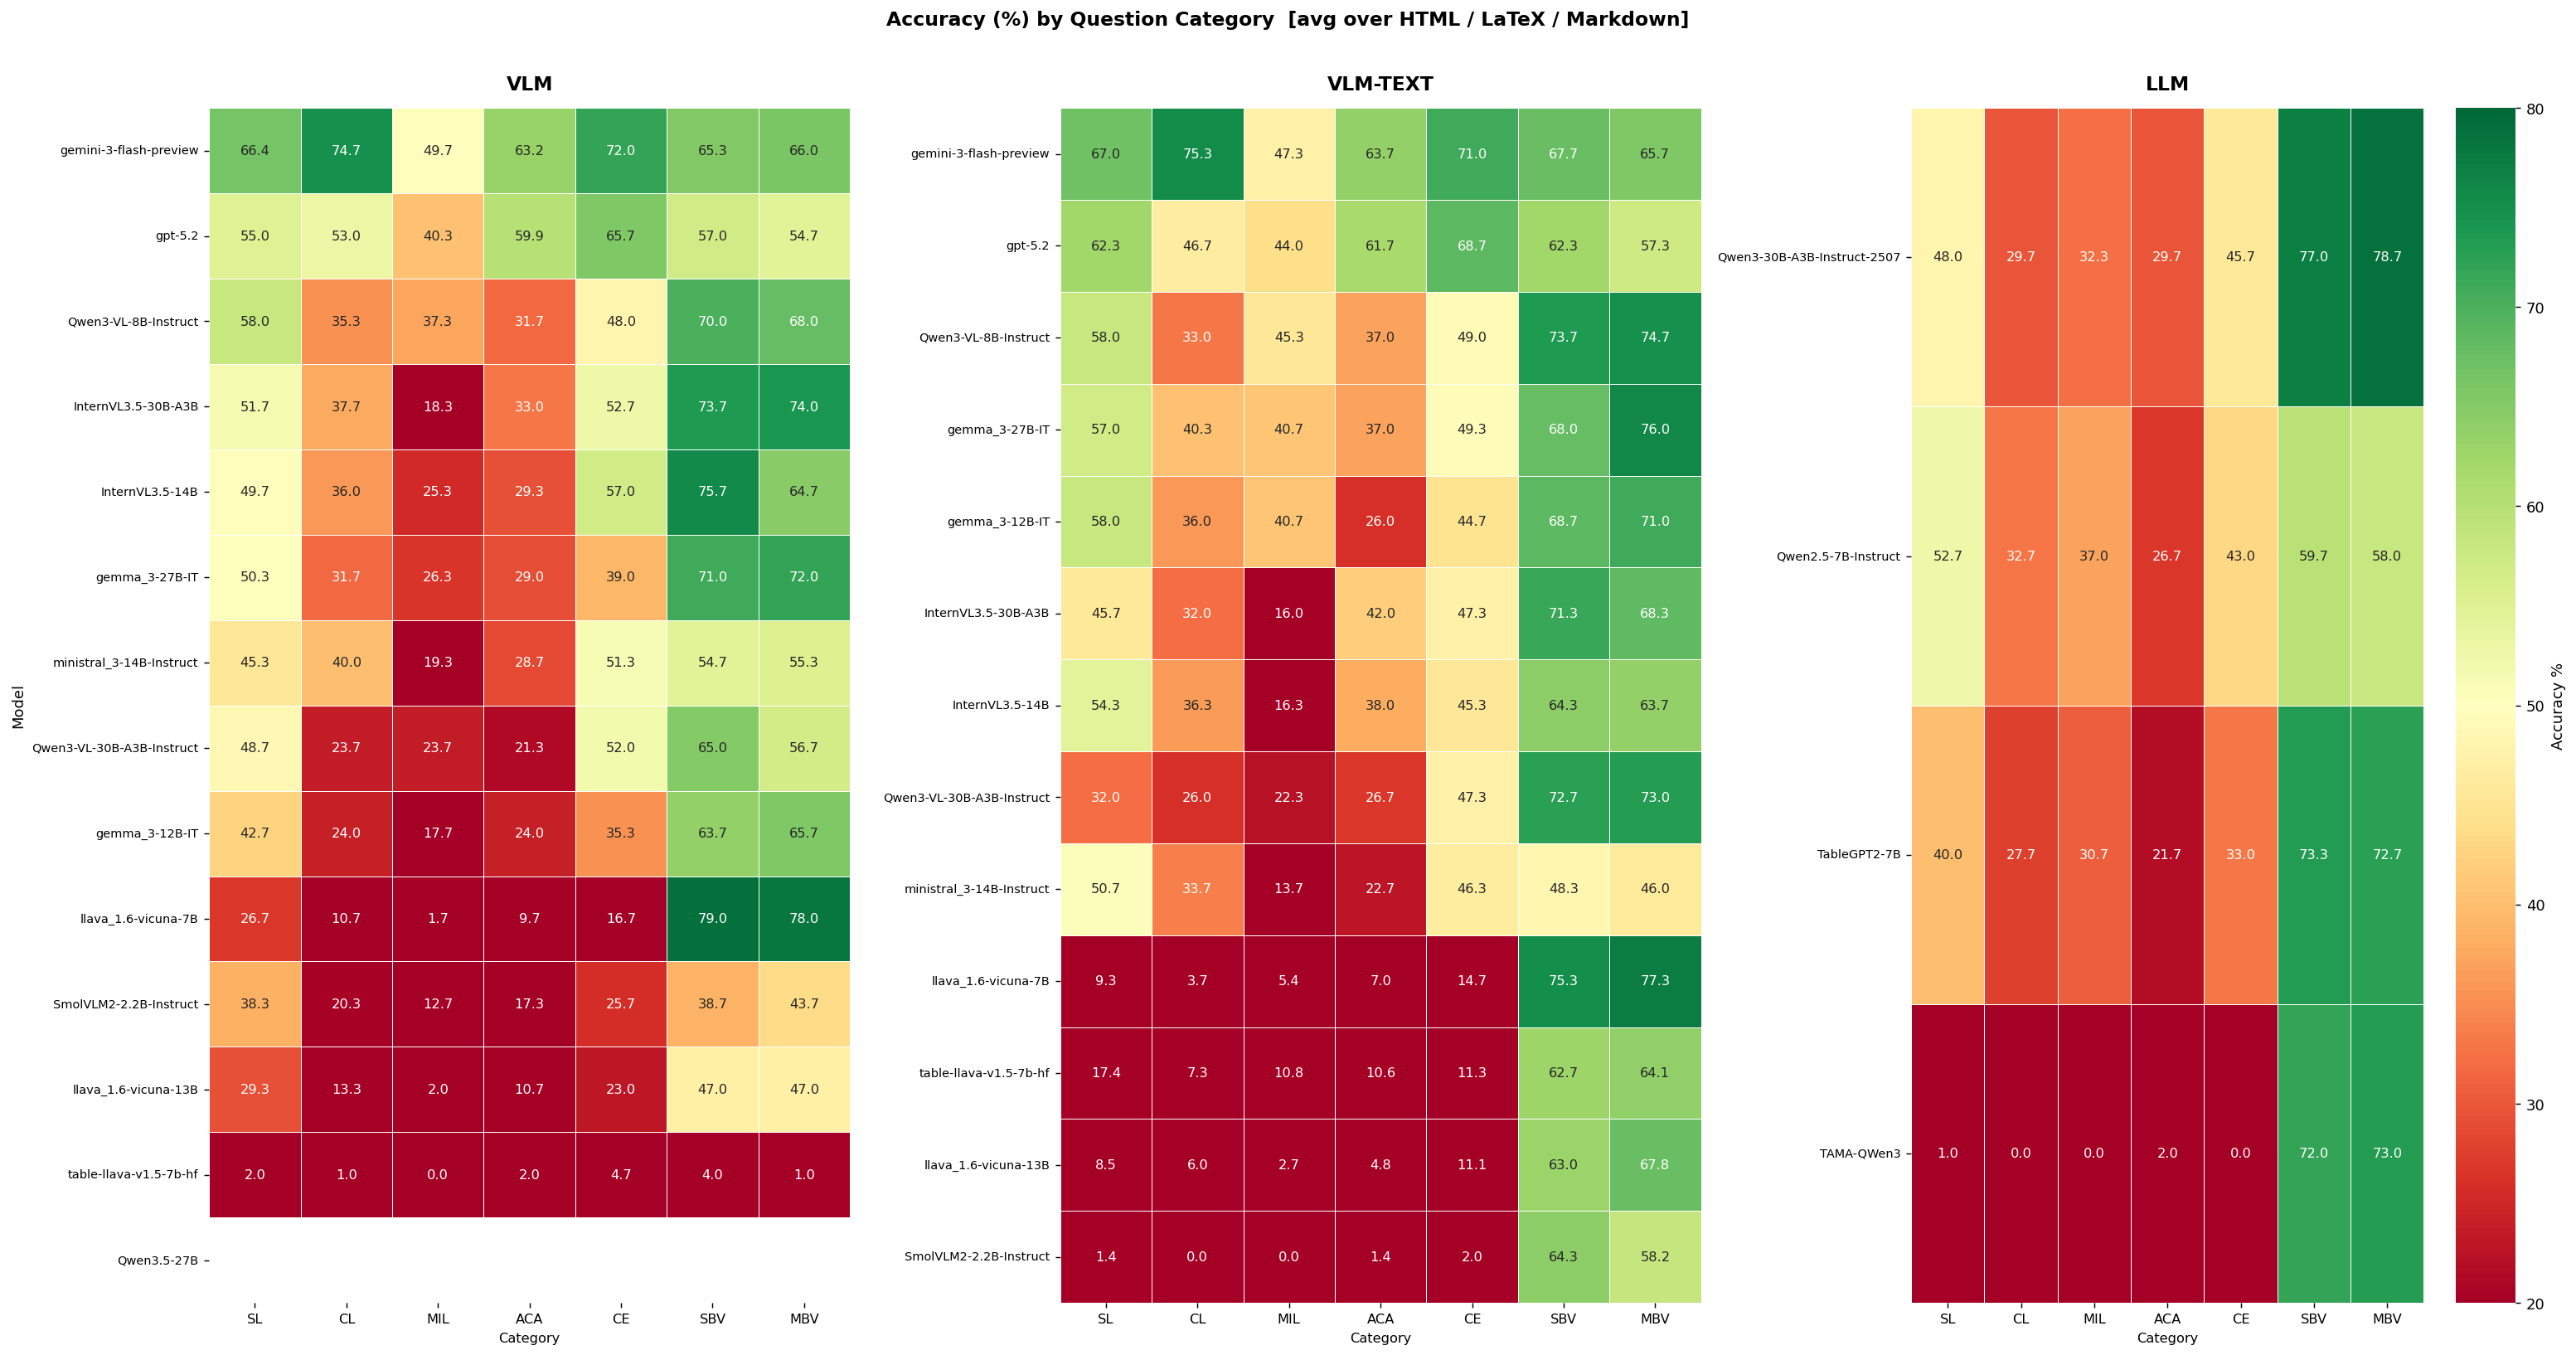

Saved → /home/momina.ahsan/TABVERSE/results/scores/fig_category_heatmap.png


In [7]:
n_models = overall['model'].nunique()
fig, axes = plt.subplots(1, 3, figsize=(24, max(5, n_models * 0.55 + 2.5)))

for ax, pipeline in zip(axes, PIPELINE_ORDER):
    sub = cat_acc[cat_acc['pipeline'] == pipeline].copy()
    if sub.empty:
        ax.set_visible(False)
        continue

    model_order = (
        overall[overall['pipeline'] == pipeline]
        .sort_values('avg_acc', ascending=False)['model'].tolist()
    )
    pivot = (
        sub.pivot_table(index='model', columns='question_category',
                        values='avg_acc', observed=True)
           .reindex(index=model_order, columns=CATEGORIES)
    )
    pivot.columns = [CAT_SHORT[c] for c in pivot.columns]

    annot = pd.DataFrame(
        [[f'{v:.1f}' if pd.notna(v) else '' for v in row]
         for row in pivot.values],
        index=pivot.index, columns=pivot.columns
    )

    sns.heatmap(
        pivot, ax=ax,
        annot=annot, fmt='', annot_kws={'size': 9},
        cmap='RdYlGn', vmin=20, vmax=80,
        linewidths=0.5,
        cbar=(pipeline == 'LLM'),
        cbar_kws={'label': 'Accuracy %'} if pipeline == 'LLM' else {}
    )
    ax.set_title(pipeline, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Category', fontsize=9)
    ax.set_ylabel('Model' if pipeline == 'VLM' else '', fontsize=10)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=8, rotation=0)

plt.suptitle(
    'Accuracy (%) by Question Category  [avg over HTML / LaTeX / Markdown]',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
fig_path = str(FINAL_CSV_DIR / 'fig_category_heatmap.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')


In [8]:
# ── Which categories are easiest / hardest globally? ──────────────────
cat_global = (
    cat_acc.groupby('question_category')['avg_acc']
           .mean().round(2)
           .sort_values(ascending=False)
           .rename('global_avg_acc')
           .reset_index()
)
cat_global['rank'] = range(1, len(cat_global) + 1)
cat_global = cat_global[['rank', 'question_category', 'global_avg_acc']]

print('Global category ranking (avg across ALL models & pipelines):')
display(cat_global)

# Per-pipeline breakdown
cat_pipe = (
    cat_acc.groupby(['pipeline', 'question_category'])['avg_acc']
           .mean().round(2).reset_index()
           .pivot(index='question_category', columns='pipeline', values='avg_acc')
           .reindex(columns=PIPELINE_ORDER)
           .sort_values('VLM', ascending=False)
)
print('\nPer-pipeline category averages (rows = categories, cols = pipelines):')
display(cat_pipe.round(2))

Global category ranking (avg across ALL models & pipelines):


,rank,question_category,global_avg_acc
0,1,Single-step Binary Verification,63.63
1,2,Multi-hop Binary Verification,63.07
2,3,Simple Lookup,40.91
3,4,Comparison & Extremum,39.09
4,5,Conditional Lookup,28.92
5,6,Aggregation / Counting / Arithmetic,27.27
6,7,Multi-Item Lookup,22.65



Per-pipeline category averages (rows = categories, cols = pipelines):


/scratch/momina.ahsan/tmp/ipykernel_789199/2874501304.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_acc.groupby(['pipeline', 'question_category'])['avg_acc']


pipeline,VLM,VLM-TEXT,LLM
question_category,,,
Single-step Binary Verification,58.82,66.33,70.50
Multi-hop Binary Verification,57.44,66.39,70.59
Simple Lookup,43.39,40.12,35.42
Comparison & Extremum,41.77,39.08,30.42
Conditional Lookup,30.87,28.95,22.50
Aggregation / Counting / Arithmetic,27.67,29.11,20.00
Multi-Item Lookup,21.10,23.48,25.00


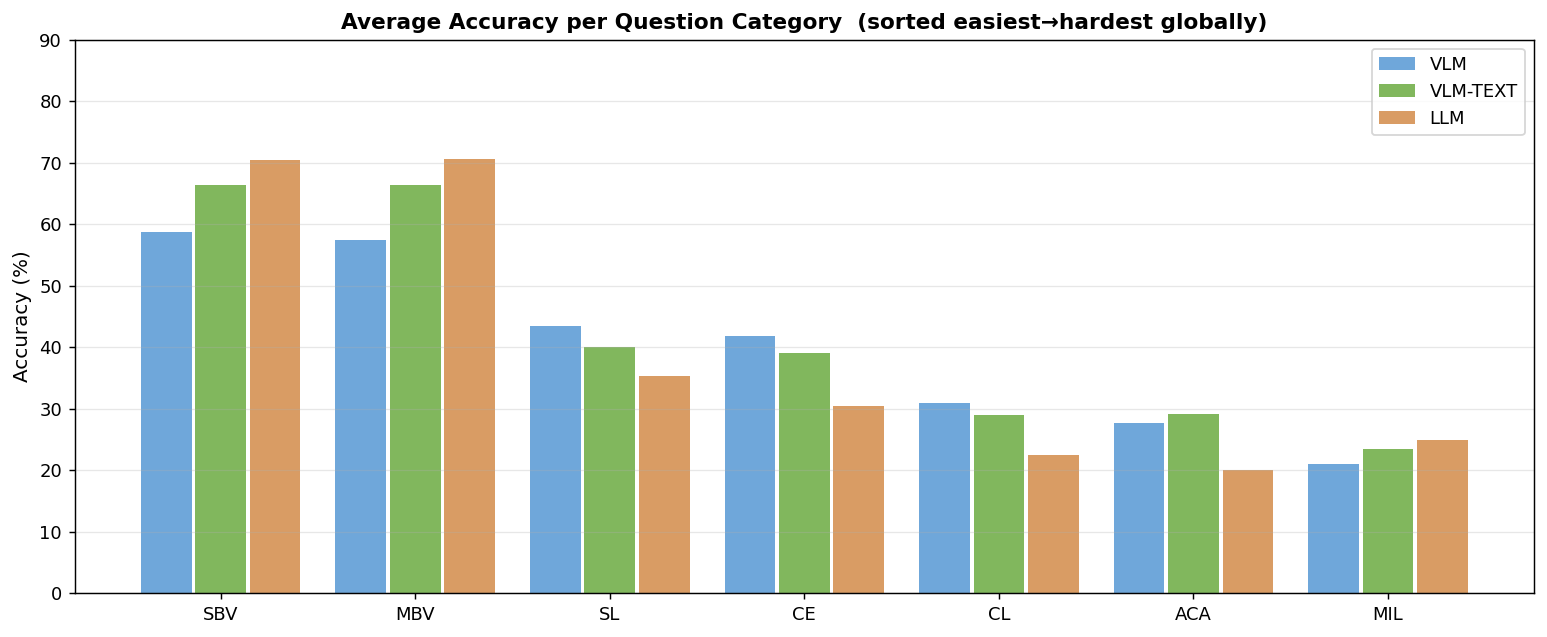

Saved → /home/momina.ahsan/TABVERSE/results/scores/fig_category_bar.png


In [9]:
PIPELINE_COLORS = {'VLM': '#5B9BD5', 'VLM-TEXT': '#70AD47', 'LLM': '#D48E4F'}

fig, ax = plt.subplots(figsize=(12, 5))

cat_names = cat_global['question_category'].tolist()
short_names = [CAT_SHORT[c] for c in cat_names]

for i, pipeline in enumerate(PIPELINE_ORDER):
    vals = [
        cat_acc[(cat_acc['pipeline'] == pipeline) &
                (cat_acc['question_category'] == c)]['avg_acc'].mean()
        for c in cat_names
    ]
    x = np.arange(len(cat_names)) + i * 0.28 - 0.28
    ax.bar(x, vals, width=0.26, label=pipeline,
           color=PIPELINE_COLORS[pipeline], alpha=0.88)

ax.set_xticks(np.arange(len(cat_names)))
ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_ylim(0, 90)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linewidth=0.7)
ax.set_title('Average Accuracy per Question Category  (sorted easiest→hardest globally)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
fig_path = str(FINAL_CSV_DIR / 'fig_category_bar.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')


In [10]:
# ── Long format: pipeline, model, category, html/latex/markdown/avg_acc ─
long_path = FINAL_CSV_DIR / 'task_category_long.csv'
cat_acc[['pipeline', 'model', 'question_category',
         'html_acc', 'latex_acc', 'markdown_acc', 'avg_acc']].to_csv(
    long_path, index=False, float_format='%.2f')
print(f'Saved (long)  → {long_path}')

# ── Wide format (paper-ready): pipeline, model, SL, CL, MIL, ACA, CE, SBV, MBV
wide_rows = []
for pipeline in PIPELINE_ORDER:
    sub = cat_wide[cat_wide['pipeline'] == pipeline].copy()
    if sub.empty:
        continue
    ord_ = (overall[overall['pipeline'] == pipeline]
            .sort_values('avg_acc', ascending=False)['model'].tolist())
    sub['model'] = pd.Categorical(sub['model'], categories=ord_, ordered=True)
    sub = sub.sort_values('model').reset_index(drop=True)
    # pipeline column already exists in cat_wide — just reorder columns
    cols = ['pipeline', 'model'] + [c for c in sub.columns if c not in ('pipeline', 'model')]
    sub = sub[cols]
    if wide_rows:
        wide_rows.append({c: '' for c in sub.columns})
    wide_rows.extend(sub.to_dict('records'))

wide_df = pd.DataFrame(wide_rows)
wide_path = FINAL_CSV_DIR / 'task_category.csv'
wide_df.to_csv(wide_path, index=False, float_format='%.2f')
print(f'Saved (wide)  → {wide_path}')

print('\nPreview (first 15 rows):')
display(wide_df.head(15).round(2))


Saved (long)  → /home/momina.ahsan/TABVERSE/results/scores/task_category_long.csv
Saved (wide)  → /home/momina.ahsan/TABVERSE/results/scores/task_category.csv

Preview (first 15 rows):


,pipeline,model,SL,CL,MIL,ACA,CE,SBV,MBV
0,VLM,gemini-3-flash-preview,66.43,74.67,49.67,63.21,72.00,65.33,66.00
1,VLM,gpt-5.2,55.01,53.00,40.33,59.87,65.67,57.00,54.67
2,VLM,Qwen3-VL-8B-Instruct,58.00,35.33,37.33,31.67,48.00,70.00,68.00
3,VLM,InternVL3.5-30B-A3B,51.67,37.67,18.33,33.00,52.67,73.67,74.00
4,VLM,InternVL3.5-14B,49.67,36.00,25.33,29.33,57.00,75.67,64.67
5,VLM,gemma_3-27B-IT,50.33,31.67,26.33,29.00,39.00,71.00,72.00
6,VLM,ministral_3-14B-Instruct,45.33,40.00,19.33,28.67,51.33,54.67,55.33
7,VLM,Qwen3-VL-30B-A3B-Instruct,48.67,23.67,23.67,21.33,52.00,65.00,56.67
8,VLM,gemma_3-12B-IT,42.67,24.00,17.67,24.00,35.33,63.67,65.67
9,VLM,llava_1.6-vicuna-7B,26.67,10.67,1.67,9.67,16.67,79.00,78.00


---
## 3. Difficulty Analysis ⭐

**350 Easy** questions vs **350 Hard** questions (balanced).  
The **gap** = Hard_acc − Easy_acc (negative = models struggle more with Hard).

In [11]:
diff_acc = compute_accuracy(df, ['pipeline', 'model', 'question_difficulty'])

# Build wide table: pipeline, model, easy_acc, hard_acc, gap
diff_rows = []
for pipeline in PIPELINE_ORDER:
    sub = diff_acc[diff_acc['pipeline'] == pipeline]
    if sub.empty:
        continue
    ord_ = (overall[overall['pipeline'] == pipeline]
            .sort_values('avg_acc', ascending=False)['model'].tolist())
    for model in ord_:
        msub = sub[sub['model'] == model]
        easy = msub[msub['question_difficulty'] == 'Easy']['avg_acc'].values
        hard = msub[msub['question_difficulty'] == 'Hard']['avg_acc'].values
        easy_val = float(easy[0]) if len(easy) > 0 and easy[0] is not None else None
        hard_val = float(hard[0]) if len(hard) > 0 and hard[0] is not None else None
        gap = round(hard_val - easy_val, 2) if (easy_val is not None and hard_val is not None) else None
        diff_rows.append({'pipeline': pipeline, 'model': model,
                          'easy_acc': easy_val, 'hard_acc': hard_val, 'gap': gap})
    diff_rows.append({'pipeline': '', 'model': '', 'easy_acc': None,
                      'hard_acc': None, 'gap': None})

diff_wide = pd.DataFrame(diff_rows)

print('Easy vs Hard accuracy (avg over 3 formats):')
for pipeline in PIPELINE_ORDER:
    sub = diff_wide[diff_wide['pipeline'] == pipeline].drop(columns='pipeline').reset_index(drop=True)
    if sub.empty:
        continue
    print(f'\n{" " + pipeline + " ":=^50}')
    display(sub.round(2))

Easy vs Hard accuracy (avg over 3 formats):

====================== VLM =======================


,model,easy_acc,hard_acc,gap
0,gemini-3-flash-preview,97.33,33.23,-64.10
1,gpt-5.2,93.14,16.91,-76.23
2,Qwen3-VL-8B-Instruct,73.62,25.90,-47.72
3,InternVL3.5-30B-A3B,68.29,29.14,-39.15
4,InternVL3.5-14B,67.33,29.14,-38.19
5,gemma_3-27B-IT,63.24,28.00,-35.24
6,ministral_3-14B-Instruct,61.24,22.95,-38.29
7,Qwen3-VL-30B-A3B-Instruct,63.71,19.43,-44.28
8,gemma_3-12B-IT,54.00,24.00,-30.00
9,llava_1.6-vicuna-7B,35.62,27.90,-7.72



==================== VLM-TEXT ====================


,model,easy_acc,hard_acc,gap
0,gemini-3-flash-preview,95.72,35.05,-60.67
1,gpt-5.2,91.43,23.71,-67.72
2,Qwen3-VL-8B-Instruct,73.33,32.57,-40.76
3,gemma_3-27B-IT,74.19,31.05,-43.14
4,gemma_3-12B-IT,67.14,31.43,-35.71
5,InternVL3.5-30B-A3B,63.52,28.67,-34.85
6,InternVL3.5-14B,64.95,26.00,-38.95
7,Qwen3-VL-30B-A3B-Instruct,60.09,25.62,-34.47
8,ministral_3-14B-Instruct,54.67,20.00,-34.67
9,llava_1.6-vicuna-7B,30.10,25.43,-4.67



====================== LLM =======================


,model,easy_acc,hard_acc,gap
0,Qwen3-30B-A3B-Instruct-2507,65.90,31.53,-34.37
1,Qwen2.5-7B-Instruct,63.05,25.43,-37.62
2,TableGPT2-7B,55.81,29.62,-26.19
3,TAMA-QWen3,22.00,20.29,-1.71


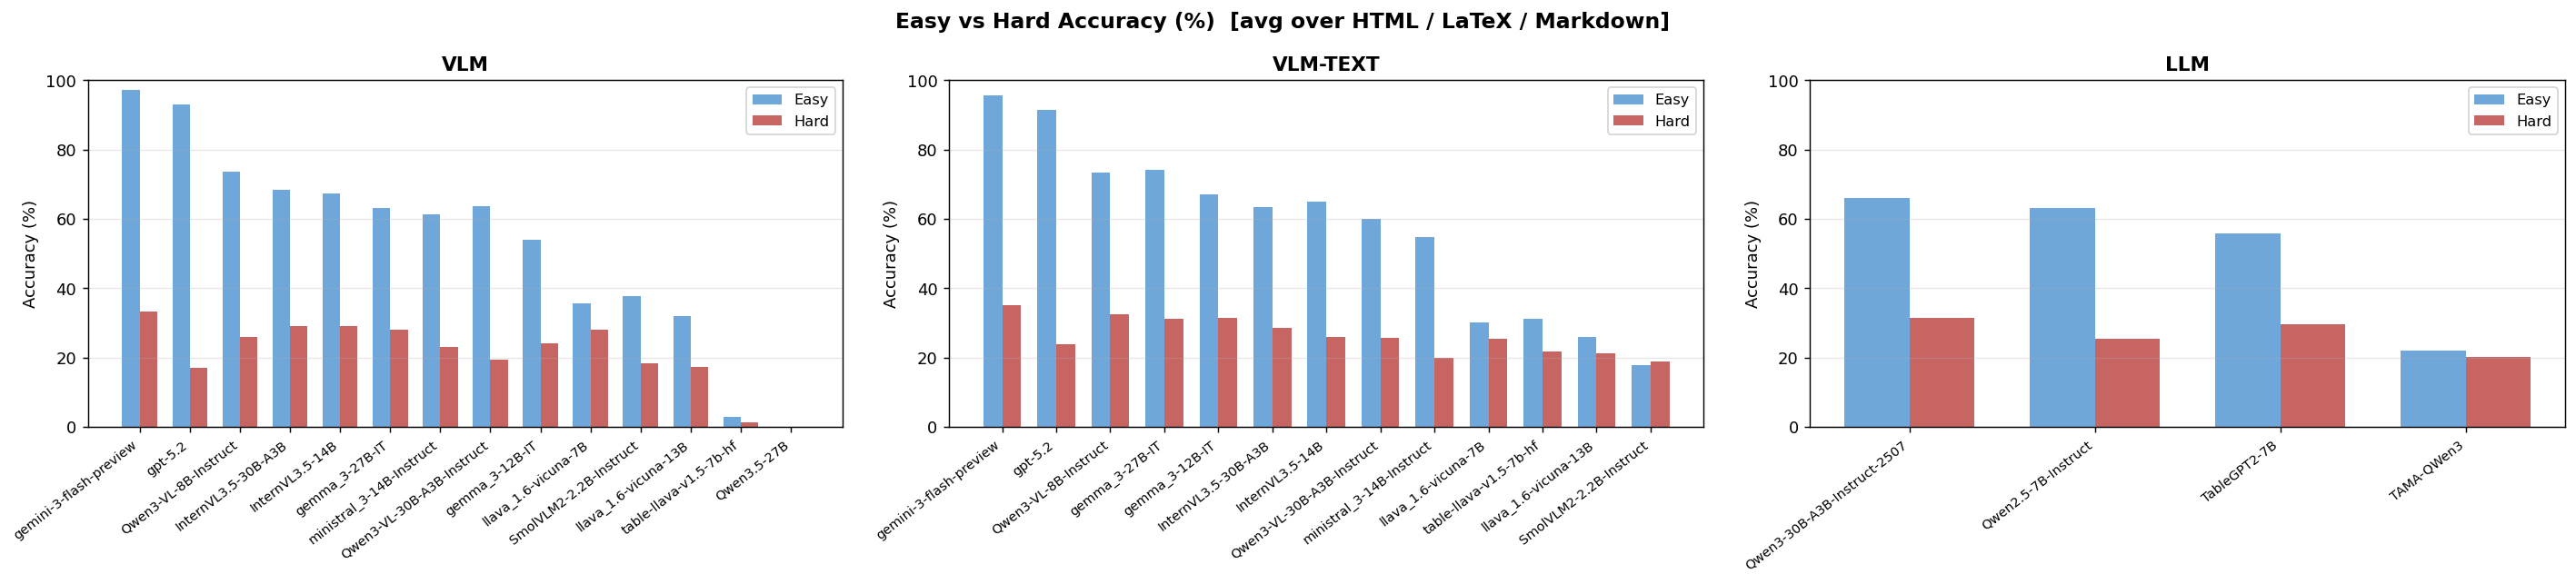

Saved → /home/momina.ahsan/TABVERSE/results/scores/fig_difficulty.png


In [12]:
colors = {'Easy': '#5B9BD5', 'Hard': '#C0504D'}
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

for ax, pipeline in zip(axes, PIPELINE_ORDER):
    sub = diff_acc[diff_acc['pipeline'] == pipeline].copy()
    if sub.empty:
        ax.set_visible(False)
        continue
    ord_ = (overall[overall['pipeline'] == pipeline]
            .sort_values('avg_acc', ascending=False)['model'].tolist())
    pivot = (
        sub.pivot_table(index='model', columns='question_difficulty',
                        values='avg_acc', observed=True)
           .reindex(index=ord_, columns=DIFFICULTIES)
    )
    x = np.arange(len(pivot))
    w = 0.35
    easy_vals = pivot.get('Easy', pd.Series([0]*len(pivot))).fillna(0).values
    hard_vals = pivot.get('Hard', pd.Series([0]*len(pivot))).fillna(0).values
    ax.bar(x - w/2, easy_vals, w, label='Easy', color=colors['Easy'], alpha=0.88)
    ax.bar(x + w/2, hard_vals, w, label='Hard', color=colors['Hard'], alpha=0.88)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=38, ha='right', fontsize=8)
    ax.set_ylabel('Accuracy (%)', fontsize=10)
    ax.set_title(pipeline, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3, linewidth=0.7)

plt.suptitle('Easy vs Hard Accuracy (%)  [avg over HTML / LaTeX / Markdown]',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig_path = str(FINAL_CSV_DIR / 'fig_difficulty.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')


In [13]:
diff_path = FINAL_CSV_DIR / 'task_difficulty.csv'
diff_wide.to_csv(diff_path, index=False, float_format='%.2f')
print(f'Saved → {diff_path}')

Saved → /home/momina.ahsan/TABVERSE/results/scores/task_difficulty.csv


---
## 4. Dataset Analysis

| Dataset | N | Primary task type |
|---------|---|-------------------|
| wikitq  | 195 | Open-ended lookup & arithmetic |
| sqa     | 157 | Sequential questions |
| hybridqa| 148 | Hybrid table+text |
| tabfact | 124 | Binary verification |
| feverous|  76 | Fact verification |

In [14]:
ds_acc = compute_accuracy(df, ['pipeline', 'model', 'dataset'])

# Wide table
ds_rows = []
for pipeline in PIPELINE_ORDER:
    sub = ds_acc[ds_acc['pipeline'] == pipeline]
    if sub.empty:
        continue
    ord_ = (overall[overall['pipeline'] == pipeline]
            .sort_values('avg_acc', ascending=False)['model'].tolist())
    for model in ord_:
        msub = sub[sub['model'] == model]
        row = {'pipeline': pipeline, 'model': model}
        for ds in DATASETS:
            vals = msub[msub['dataset'] == ds]['avg_acc'].values
            row[ds] = round(float(vals[0]), 2) if len(vals) > 0 and vals[0] is not None else None
        ds_rows.append(row)
    ds_rows.append({k: '' for k in ['pipeline', 'model'] + DATASETS})

ds_wide = pd.DataFrame(ds_rows)

print('Dataset accuracy (avg over 3 formats):')
for pipeline in PIPELINE_ORDER:
    sub = ds_wide[ds_wide['pipeline'] == pipeline].drop(columns='pipeline').reset_index(drop=True)
    if sub.empty:
        continue
    print(f'\n{" " + pipeline + " ":=^60}')
    display(sub.round(2))

Dataset accuracy (avg over 3 formats):

=========================== VLM ============================


,model,wikitq,hybridqa,sqa,tabfact,feverous
0,gemini-3-flash-preview,75.08,63.29,55.42,70.70,56.14
1,gpt-5.2,70.78,41.89,48.62,59.41,46.93
2,Qwen3-VL-8B-Instruct,53.50,27.25,43.74,72.31,59.65
3,InternVL3.5-30B-A3B,50.94,28.60,34.18,78.23,64.03
4,InternVL3.5-14B,48.38,31.76,36.73,73.92,61.84
5,gemma_3-27B-IT,40.68,29.06,34.82,74.19,66.23
6,ministral_3-14B-Instruct,47.87,27.48,33.54,51.61,57.89
7,Qwen3-VL-30B-A3B-Instruct,45.30,17.12,36.73,61.83,56.58
8,gemma_3-12B-IT,32.99,22.07,30.36,67.48,58.77
9,llava_1.6-vicuna-7B,16.24,9.01,11.67,92.74,57.89



========================= VLM-TEXT =========================


,model,wikitq,hybridqa,sqa,tabfact,feverous
0,gemini-3-flash-preview,74.53,64.41,53.93,72.04,56.58
1,gpt-5.2,75.38,37.84,52.87,63.17,50.88
2,Qwen3-VL-8B-Instruct,54.70,25.22,51.38,79.30,62.72
3,gemma_3-27B-IT,52.48,31.53,49.04,77.96,60.09
4,gemma_3-12B-IT,42.91,32.88,47.13,75.27,59.65
5,InternVL3.5-30B-A3B,52.30,26.13,28.45,72.58,62.28
6,InternVL3.5-14B,53.16,29.73,28.66,63.98,60.96
7,Qwen3-VL-30B-A3B-Instruct,41.88,17.34,31.85,74.19,66.67
8,ministral_3-14B-Instruct,46.16,23.20,29.09,41.40,52.63
9,llava_1.6-vicuna-7B,10.98,2.93,7.85,89.47,56.94



=========================== LLM ============================


,model,wikitq,hybridqa,sqa,tabfact,feverous
0,Qwen3-30B-A3B-Instruct-2507,46.49,21.85,41.19,80.64,70.18
1,Qwen2.5-7B-Instruct,45.30,24.32,44.38,59.41,55.26
2,TableGPT2-7B,38.97,17.57,33.33,79.03,61.41
3,TAMA-QWen3,0.00,0.00,0.00,87.37,52.19


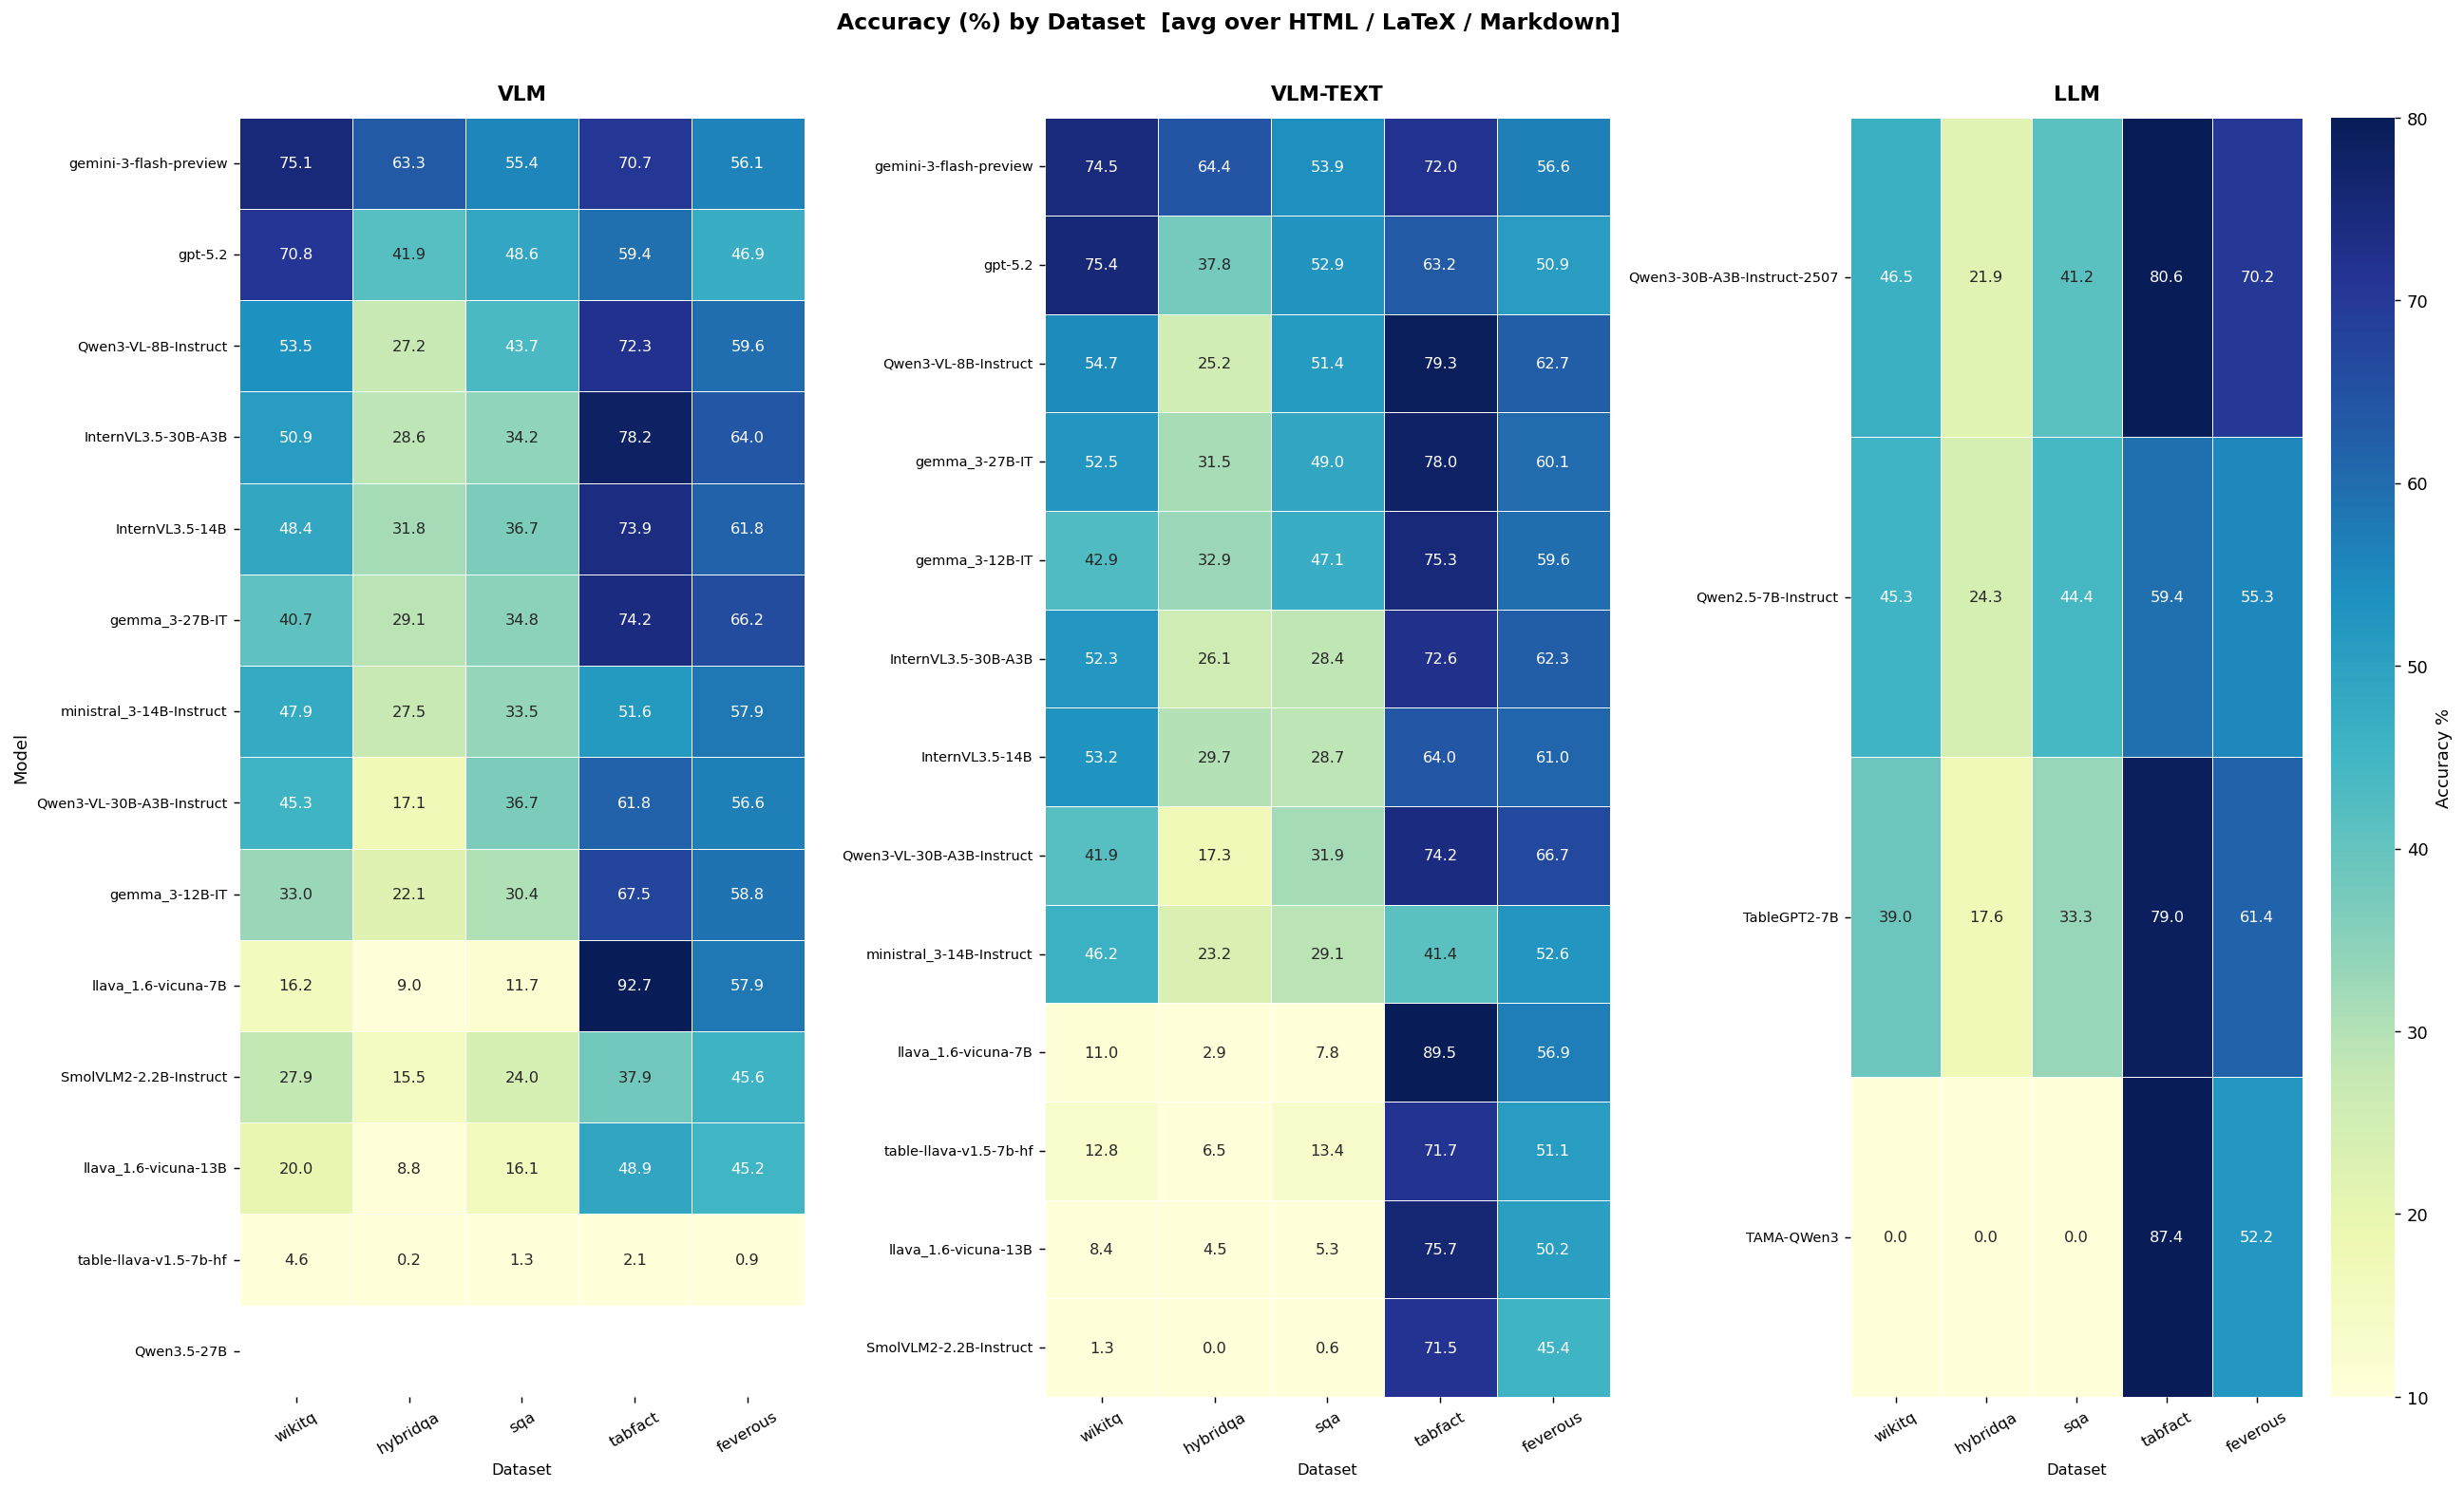

Saved → /home/momina.ahsan/TABVERSE/results/scores/fig_dataset_heatmap.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, max(4, n_models * 0.55 + 2)))

for ax, pipeline in zip(axes, PIPELINE_ORDER):
    sub = ds_acc[ds_acc['pipeline'] == pipeline].copy()
    if sub.empty:
        ax.set_visible(False)
        continue
    ord_ = (overall[overall['pipeline'] == pipeline]
            .sort_values('avg_acc', ascending=False)['model'].tolist())
    pivot = (
        sub.pivot_table(index='model', columns='dataset',
                        values='avg_acc', observed=True)
           .reindex(index=ord_, columns=DATASETS)
    )
    annot = pd.DataFrame(
        [[f'{v:.1f}' if pd.notna(v) else '' for v in row]
         for row in pivot.values],
        index=pivot.index, columns=pivot.columns
    )
    sns.heatmap(
        pivot, ax=ax,
        annot=annot, fmt='', annot_kws={'size': 9},
        cmap='YlGnBu', vmin=10, vmax=80,
        linewidths=0.5,
        cbar=(pipeline == 'LLM'),
        cbar_kws={'label': 'Accuracy %'} if pipeline == 'LLM' else {}
    )
    ax.set_title(pipeline, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Dataset', fontsize=9)
    ax.set_ylabel('Model' if pipeline == 'VLM' else '', fontsize=10)
    ax.tick_params(axis='x', labelsize=9, rotation=30)
    ax.tick_params(axis='y', labelsize=8, rotation=0)

plt.suptitle('Accuracy (%) by Dataset  [avg over HTML / LaTeX / Markdown]',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = str(FINAL_CSV_DIR / 'fig_dataset_heatmap.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')


In [16]:
ds_path = FINAL_CSV_DIR / 'task_dataset.csv'
ds_wide.to_csv(ds_path, index=False, float_format='%.2f')
print(f'Saved → {ds_path}')

Saved → /home/momina.ahsan/TABVERSE/results/scores/task_dataset.csv


---
## 5. Modality Gap Analysis (Δ)

$$\Delta = \text{avg\_acc(VLM-TEXT)} - \text{avg\_acc(VLM)}$$

For each VLM model that appears in **both** pipelines:

| Sign | Meaning |
|------|---------|
| Δ < 0 | Image input **helps** — VLM beats VLM-TEXT |
| Δ > 0 | Text-only is **better** — image adds noise or hurts |
| Δ ≈ 0 | Modality makes no difference |

Models sorted by Δ (ascending, i.e. most image-favourable first).


Modality Gap  (Δ = VLM-TEXT − VLM, negative = image helps):


,model,vlm_acc,vlmt_acc,delta
0,SmolVLM2-2.2B-Instruct,28.09,18.32,-9.77
1,ministral_3-14B-Instruct,42.09,37.33,-4.76
2,llava_1.6-vicuna-7B,31.76,27.81,-3.95
3,InternVL3.5-14B,48.24,45.48,-2.76
4,InternVL3.5-30B-A3B,48.72,46.10,-2.62
5,llava_1.6-vicuna-13B,24.62,23.64,-0.98
6,gemini-3-flash-preview,65.33,65.38,0.05
7,Qwen3-VL-30B-A3B-Instruct,41.57,42.86,1.29
8,gpt-5.2,55.08,57.57,2.49
9,Qwen3-VL-8B-Instruct,49.76,52.95,3.19


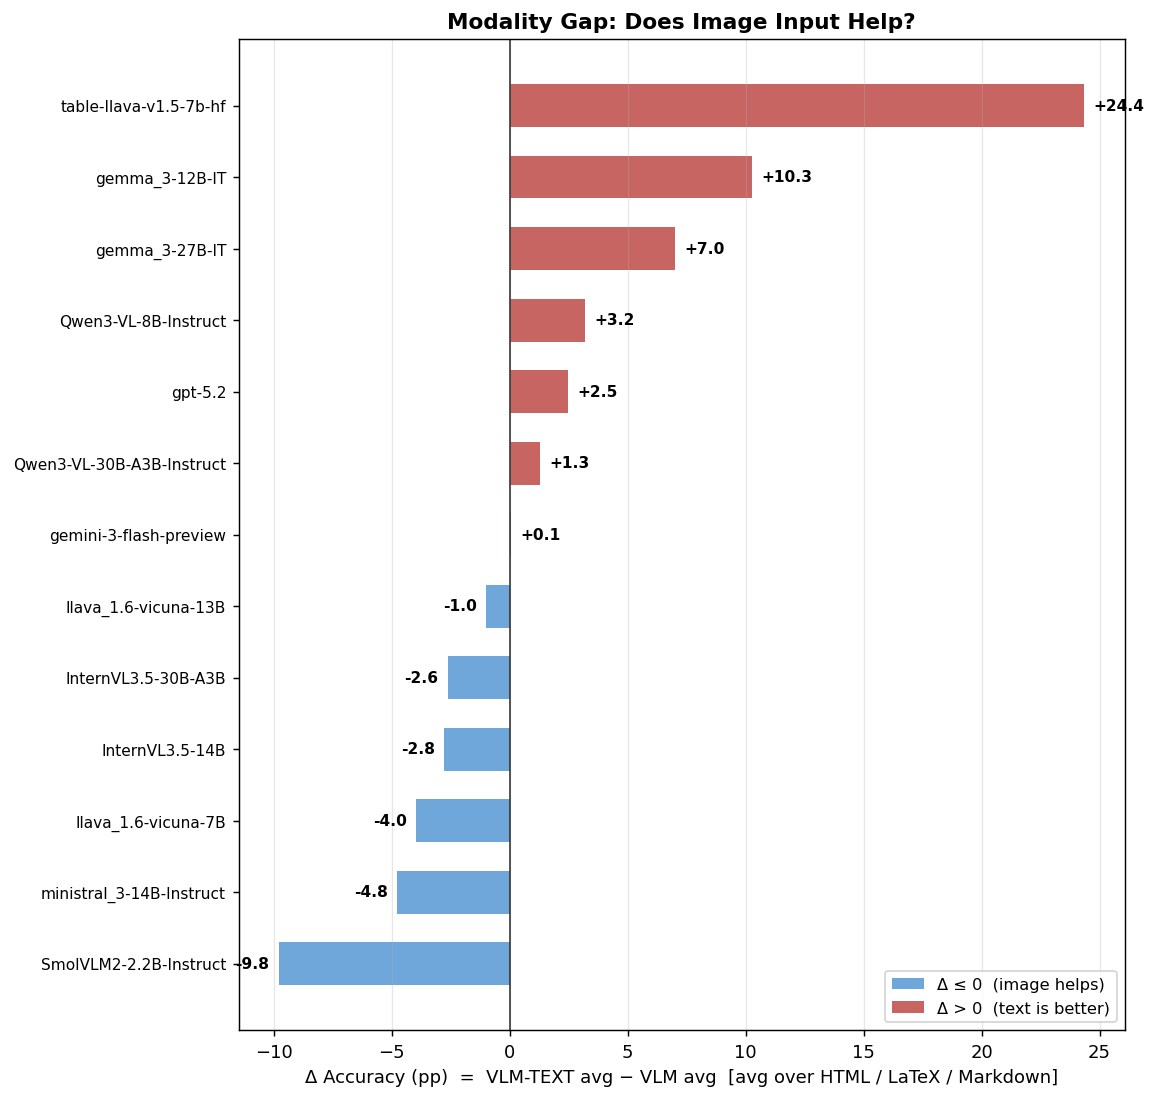

Saved → /home/momina.ahsan/TABVERSE/results/scores/fig_modality_gap.png
Saved → /home/momina.ahsan/TABVERSE/results/scores/task_modality_gap.csv


In [17]:
# ── Modality Gap: Δ = VLM-TEXT avg_acc − VLM avg_acc ─────────────────
vlm_acc  = (overall[overall['pipeline'] == 'VLM']
            [['model', 'avg_acc']].rename(columns={'avg_acc': 'vlm_acc'}))
vlmt_acc = (overall[overall['pipeline'] == 'VLM-TEXT']
            [['model', 'avg_acc']].rename(columns={'avg_acc': 'vlmt_acc'}))

delta_df = pd.merge(vlm_acc, vlmt_acc, on='model', how='inner')
delta_df['delta'] = (delta_df['vlmt_acc'] - delta_df['vlm_acc']).round(2)
delta_df = delta_df.sort_values('delta').reset_index(drop=True)

print('Modality Gap  (Δ = VLM-TEXT − VLM, negative = image helps):')
display(delta_df.round(2))

# ── Horizontal bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, max(4, len(delta_df) * 0.52 + 1.8)))

bar_colors = ['#5B9BD5' if v <= 0 else '#C0504D' for v in delta_df['delta']]
bars = ax.barh(delta_df['model'], delta_df['delta'],
               color=bar_colors, height=0.6, alpha=0.88)

for bar, val in zip(bars, delta_df['delta']):
    pad = 0.4
    ha  = 'left' if val >= 0 else 'right'
    ax.text(val + (pad if val >= 0 else -pad),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.1f}', va='center', ha=ha, fontsize=8.5, fontweight='bold')

ax.axvline(0, color='#333333', linewidth=0.9)
ax.set_xlabel(
    'Δ Accuracy (pp)  =  VLM-TEXT avg − VLM avg  [avg over HTML / LaTeX / Markdown]',
    fontsize=10)
ax.set_title('Modality Gap: Does Image Input Help?', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linewidth=0.7)
ax.tick_params(axis='y', labelsize=8.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#5B9BD5', alpha=0.88, label='Δ ≤ 0  (image helps)'),
    Patch(facecolor='#C0504D', alpha=0.88, label='Δ > 0  (text is better)'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
fig_path = str(FINAL_CSV_DIR / 'fig_modality_gap.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

# ── Save CSV ───────────────────────────────────────────────────────────
gap_path = FINAL_CSV_DIR / 'task_modality_gap.csv'
delta_df.to_csv(gap_path, index=False, float_format='%.2f')
print(f'Saved → {gap_path}')


---
## 6. All Exported Files

| File | Contents |
|------|----------|
| `task.csv` | Primary paper table: overall accuracy per format |
| `task_category.csv` | Wide: model × category avg accuracy |
| `task_category_long.csv` | Long: per (pipeline, model, category, format) |
| `task_difficulty.csv` | Easy / Hard / gap per model |
| `task_dataset.csv` | Wide: model × dataset avg accuracy |
| `task_modality_gap.csv` | Δ = VLM-TEXT − VLM per model |
| `fig_category_heatmap.png` | Category accuracy heatmap |
| `fig_category_bar.png` | Category accuracy bar chart |
| `fig_difficulty.png` | Easy vs Hard grouped bar chart |
| `fig_dataset_heatmap.png` | Dataset accuracy heatmap |
| `fig_modality_gap.png` | Modality gap Δ horizontal bar chart |


In [18]:
print('Files in results/scores/:')
for p in sorted(FINAL_CSV_DIR.iterdir()):
    size = p.stat().st_size
    print(f'  {p.name:<40}  {size:>8,} bytes')

Files in results/scores/:
  fig_category_bar.png                        46,820 bytes
  fig_category_heatmap.png                   371,064 bytes
  fig_dataset_heatmap.png                    326,155 bytes
  fig_difficulty.png                         140,808 bytes
  fig_modality_gap.png                        98,358 bytes
  generation                                       4 bytes
  suc                                              8 bytes
  task                                             3 bytes
  task_category.csv                            1,983 bytes
  task_category_long.csv                      15,818 bytes
  task_dataset.csv                             1,725 bytes
  task_difficulty.csv                          1,400 bytes
  task_modality_gap.csv                          513 bytes


---
## 7. Sample HTML Table Images

HTML table renderings for three specific records fetched from `data/4-representations/html/`.

| ID  | Image ID   | Dataset  | Category                     | Difficulty |
|-----|-----------|----------|------------------------------|------------|
| 116 | 02d211da  | sqa      | Multi-Item Lookup            | Easy       |
| 156 | fb0a03af  | wikitq   | Aggregation / Counting / Arithmetic | Easy |
| 310 | 1bdd99cd  | feverous | Multi-hop Binary Verification | Easy      |


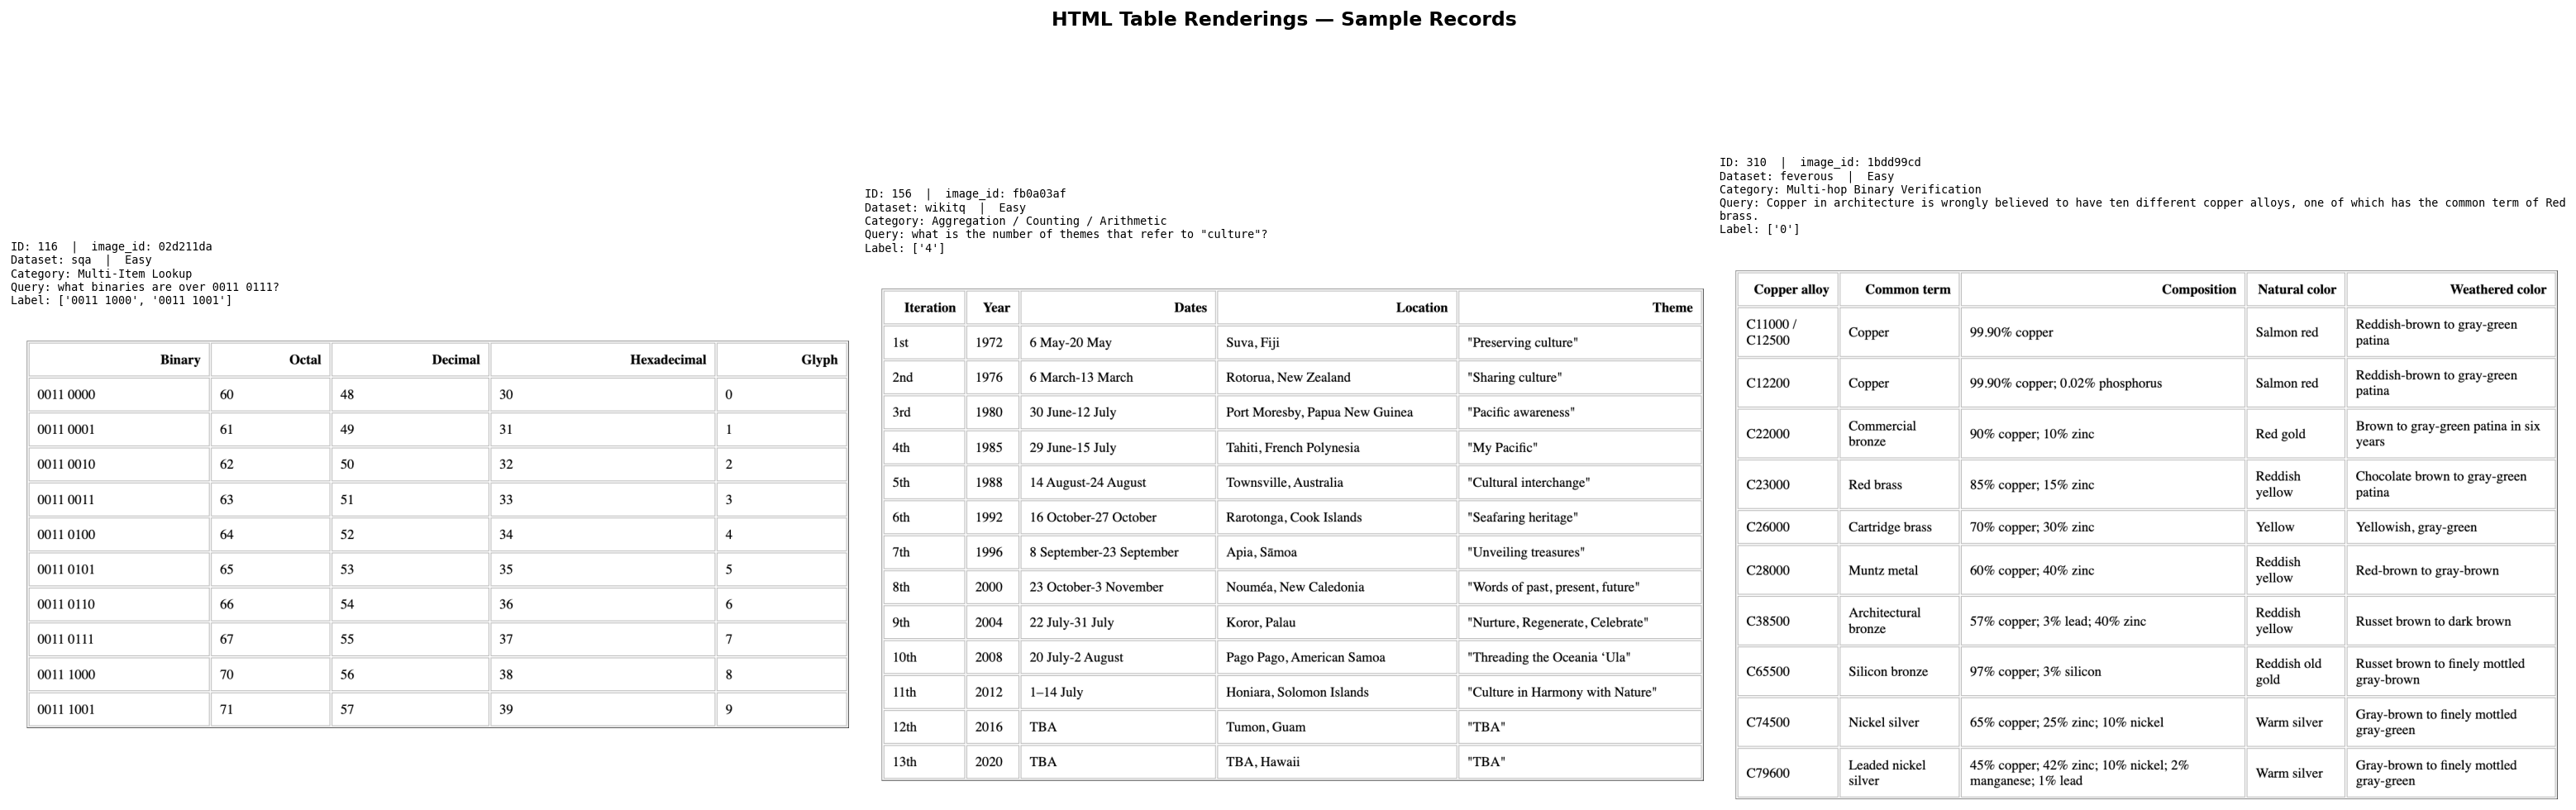

Saved → /home/momina.ahsan/TABVERSE/results/scores/fig_sample_html_tables.png


In [19]:
from IPython.display import display, Image as IPImage
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

HTML_IMG_DIR = TABVERSE_ROOT / 'data' / '4-representations' / 'html'

SAMPLE_RECORDS = [
    {
        'id': 116,
        'image_id': '02d211da',
        'query': 'what binaries are over 0011 0111?',
        'label': ['0011 1000', '0011 1001'],
        'question_category': 'Multi-Item Lookup',
        'question_difficulty': 'Easy',
        'dataset': 'sqa',
    },
    {
        'id': 156,
        'image_id': 'fb0a03af',
        'query': 'what is the number of themes that refer to "culture"?',
        'label': ['4'],
        'question_category': 'Aggregation / Counting / Arithmetic',
        'question_difficulty': 'Easy',
        'dataset': 'wikitq',
    },
    {
        'id': 310,
        'image_id': '1bdd99cd',
        'query': 'Copper in architecture is wrongly believed to have ten different copper alloys, '
                 'one of which has the common term of Red brass.',
        'label': ['0'],
        'question_category': 'Multi-hop Binary Verification',
        'question_difficulty': 'Easy',
        'dataset': 'feverous',
    },
]

fig, axes = plt.subplots(1, 3, figsize=(24, 9))

for ax, rec in zip(axes, SAMPLE_RECORDS):
    img_path = HTML_IMG_DIR / f"{rec['image_id']}.png"
    img = mpimg.imread(str(img_path))
    ax.imshow(img)
    ax.axis('off')

    caption = (
        f"ID: {rec['id']}  |  image_id: {rec['image_id']}\n"
        f"Dataset: {rec['dataset']}  |  {rec['question_difficulty']}\n"
        f"Category: {rec['question_category']}\n"
        f"Query: {rec['query']}\n"
        f"Label: {rec['label']}"
    )
    ax.set_title(caption, fontsize=7.5, loc='left', pad=8,
                 wrap=True, family='monospace')

plt.suptitle('HTML Table Renderings — Sample Records',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = str(FINAL_CSV_DIR / 'fig_sample_html_tables.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')
